# Sentisis EDA

In [1]:
from typing import Any, cast

import emoji
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from model.data import LABELS, load_splits, prepare_split

## Load and frame the data

In [2]:
splits = load_splits()
frames: list[pd.DataFrame] = []
for split_name in ("train", "validation", "test"):
    rows = cast(dict[str, Any], splits[split_name])
    labels = [int(value) for value in rows["label"]]
    frames.append(
        pd.DataFrame(
            {
                "text": [str(text) for text in rows["text"]],
                "label": labels,
                "label_name": [LABELS[value] for value in labels],
                "split": split_name,
            }
        )
    )
dataset = pd.concat(frames, ignore_index=True)
dataset["char_count"] = dataset["text"].str.len()
dataset["word_count"] = dataset["text"].str.split().map(len)

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59899 entries, 0 to 59898
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        59899 non-null  object
 1   label       59899 non-null  int64 
 2   label_name  59899 non-null  object
 3   split       59899 non-null  object
 4   char_count  59899 non-null  int64 
 5   word_count  59899 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 2.7+ MB


In [4]:
dataset.head()

,text,label,label_name,split,char_count,word_count
0,"""QT @user In the original draft of the 7th boo...",2,positive,train,119,18
1,"""Ben Smith / Smith (concussion) remains out of...",1,neutral,train,84,14
2,Sorry bout the stream last night I crashed out...,1,neutral,train,124,24
3,Chase Headley's RBI double in the 8th inning o...,1,neutral,train,139,23
4,@user Alciato: Bee will invest 150 million in ...,2,positive,train,114,21


## Dataset shape and label balance

,rows
split,
test,12284
train,45615
validation,2000


label_name,negative,neutral,positive
split,,,
test,3972,5937,2375
train,7093,20673,17849
validation,312,869,819


label_name,negative,neutral,positive
split,,,
test,32.33,48.33,19.33
train,15.55,45.32,39.13
validation,15.60,43.45,40.95


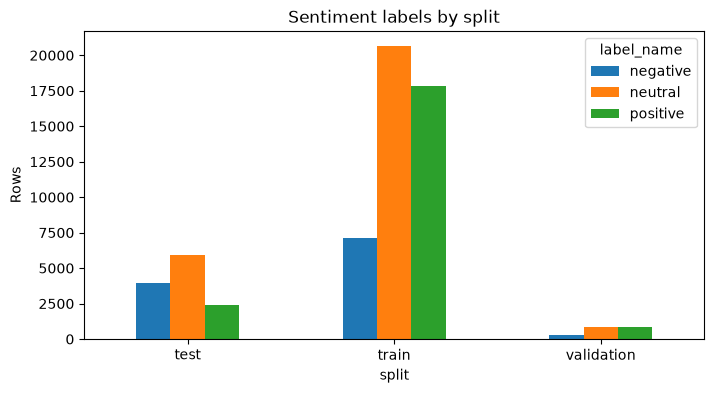

In [5]:
display(dataset.groupby("split").size().rename("rows").to_frame())
label_table = pd.crosstab(dataset["split"], dataset["label_name"])
label_percent = label_table.div(label_table.sum(axis=1), axis=0).mul(100).round(2)
display(label_table)
display(label_percent)
label_table.plot.bar(figsize=(8, 4), title="Sentiment labels by split")
plt.ylabel("Rows")
plt.xticks(rotation=0)
plt.show()

## Text-length distributions

char_count                                           \
                           count    mean    std   min   25%    50%    75%   
split      label_name                                                       
test       negative       3972.0  101.38  27.63   9.0  84.0  109.0  122.0   
           neutral        5937.0   87.54  29.66   7.0  65.0   90.0  112.0   
           positive       2375.0   84.07  30.22   6.0  62.0   85.0  108.0   
train      negative       7093.0  112.12  25.01  29.0  96.0  116.0  132.0   
           neutral       20673.0  105.99  26.48  10.0  88.0  112.0  126.0   
           positive      17849.0  105.96  26.23  17.0  88.0  111.0  127.0   
validation negative        312.0  112.35  26.28  33.0  98.0  119.5  133.0   
           neutral         869.0  106.67  26.28  28.0  89.0  113.0  125.0   
           positive        819.0  106.63  25.92  28.0  89.0  113.0  127.0   

                             word_count                                      \
                         max      count   mean   std  min   25%   50%   75%   
split      label_name                                                         
test       negative    140.0     3972.0  16.80  5.24  1.0  13.0  17.0  21.0   
           neutral     141.0     5937.0  13.99  5.41  1.0  10.0  14.0  18.0   
           positive    141.0     2375.0  13.78  5.65  1.0  10.0  13.0  18.0   
train      negative    184.0     7093.0  20.22  4.76  4.0  17.0  21.0  24.0   
           neutral     200.0    20673.0  18.98  4.92  1.0  16.0  19.0  23.0   
           positive    185.0    17849.0  19.15  4.97  4.0  16.0  19.0  23.0   
validation negative    160.0      312.0  20.30  4.96  7.0  17.0  21.0  24.0   
           neutral     170.0      869.0  19.22  4.96  4.0  16.0  20.0  23.0   
           positive    169.0      819.0  19.36  5.07  5.0  16.0  20.0  23.0   

                             
                        max  
split      label_name        
test       negative    32.0  
           neutral     31.0  
           positive    32.0  
train      negative    35.0  
           neutral     33.0  
           positive    34.0  
validation negative    31.0  
           neutral     31.0  
           positive    31.0

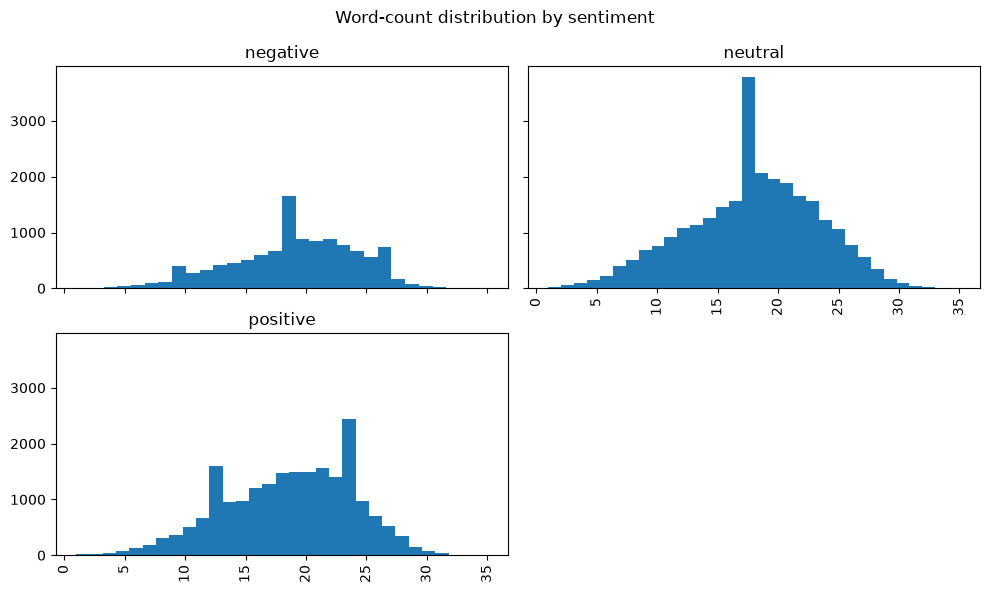

In [6]:
length_stats = dataset.groupby(["split", "label_name"])[["char_count", "word_count"]]
display(length_stats.describe().round(2))
dataset.hist(
    column="word_count", by="label_name", figsize=(10, 6), bins=30, sharex=True, sharey=True
)
plt.suptitle("Word-count distribution by sentiment")
plt.tight_layout()
plt.show()

## Data-quality and leakage checks

In [7]:
quality = pd.Series(
    {
        "rows": len(dataset),
        "empty_text": int(dataset["text"].str.strip().eq("").sum()),
        "duplicate_text_rows": int(dataset["text"].duplicated(keep=False).sum()),
        "invalid_labels": int((~dataset["label"].isin(LABELS)).sum()),
    }
)
display(quality.to_frame("value"))
cross_split = dataset.groupby("text")["split"].nunique()
print(f"exact raw texts crossing split boundaries: {(cross_split > 1).sum():,}")
sizes = "/".join(f"{len(splits[name]):,}" for name in ("train", "validation", "test"))
print(f"train/validation/test sizes: {sizes}")

,value
rows,59899
empty_text,0
duplicate_text_rows,54
invalid_labels,0


exact raw texts crossing split boundaries: 0
train/validation/test sizes: 45,615/2,000/12,284


## Social-text features by split

,train,validation,test
url,0.20,0.25,3.06
mention,29.44,31.05,40.67
hashtag,18.64,17.55,38.95
uppercase_token,28.67,28.90,26.46
repeated_punctuation,5.65,5.70,2.85
emoji,0.00,0.00,6.59


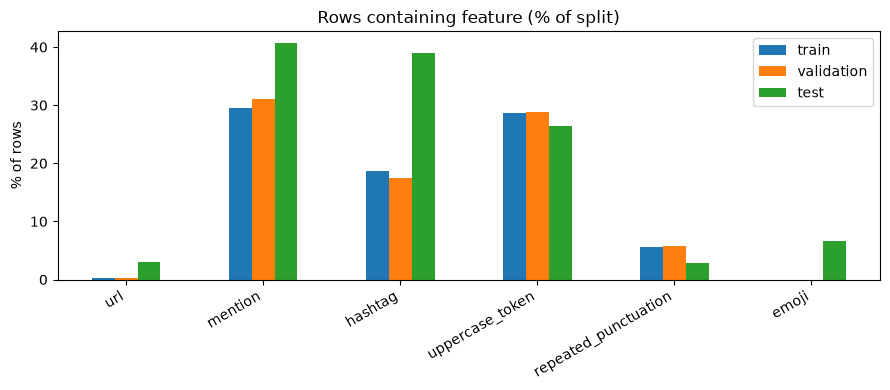

In [8]:
feature_patterns = {
    "url": r"(?:https?://|www\.)\S+",
    "mention": r"@\w{1,15}\b",
    "hashtag": r"(?<!\w)#\w+",
    "uppercase_token": r"\b[A-Z]{2,}\b",
    "repeated_punctuation": r"[!?]{2,}",
}
split_order = ["train", "validation", "test"]
feature_share = pd.DataFrame(index=split_order, dtype=float)
for name, pattern in feature_patterns.items():
    matches = dataset["text"].str.contains(pattern, regex=True, na=False)
    feature_share[name] = matches.groupby(dataset["split"]).mean().mul(100)
has_emoji = dataset["text"].map(lambda text: emoji.emoji_count(text) > 0)
feature_share["emoji"] = has_emoji.groupby(dataset["split"]).mean().mul(100)
display(feature_share.round(2).T)
feature_share.T.plot.bar(figsize=(9, 4), title="Rows containing feature (% of split)")
plt.ylabel("% of rows")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Encoding artifacts and what the cleaner does with them

TweetEval carries escaped punctuation and HTML entities in the raw text. Left alone these
survive `normalize` and are shredded into junk tokens by `to_bow`, so they are counted here
alongside their effect on the cleaned output.

In [9]:
artifact_patterns = {
    "escaped_unicode": r"\\u[0-9a-fA-F]{4}",
    "html_entity": r"&[a-zA-Z]+;",
    "wrapping_quote": r'^"',
}
artifact_rows = pd.DataFrame(index=split_order, dtype=int)
for name, pattern in artifact_patterns.items():
    matches = dataset["text"].str.contains(pattern, regex=True, na=False)
    artifact_rows[name] = matches.groupby(dataset["split"]).sum()
display(artifact_rows.T)

junk_tokens = {}
for split_name in split_order:
    bow_texts, _ = prepare_split(splits, split_name, bow=True)
    padded = [f" {text} " for text in bow_texts]
    junk_tokens[split_name] = {
        "rows": len(padded),
        "contains ' u c '": sum(1 for text in padded if " u c " in text),
        "contains ' amp '": sum(1 for text in padded if " amp " in text),
    }
display(pd.DataFrame(junk_tokens))

,train,validation,test
escaped_unicode,5111,206,0
html_entity,1917,88,4
wrapping_quote,9368,397,137


,train,validation,test
rows,45615,2000,12284
contains ' u c ',1,0,2
contains ' amp ',4,0,0


## Representative examples by label

In [10]:
for label_name in LABELS.values():
    print(f"--- {label_name} ---")
    matching = dataset.loc[dataset["label_name"].eq(label_name), ["text", "word_count"]]
    examples = matching.sample(n=min(5, len(matching)), random_state=42)
    display(examples.reset_index(drop=True))

--- negative ---


,text,word_count
0,"""Tho I respect his decision, I don't agree wit...",27
1,"""Charlie Hebdo may quite rightly enjoy freedom...",25
2,Jiujitsu test tomorrow... I think it might be ...,19
3,Luna is taking a break today\u002c not perfect...,25
4,If you violate a restraining order and have to...,22


--- neutral ---


,text,word_count
0,Sore left knee keeping Hamilton out: Rangers o...,19
1,"""Caitlyn Jenner and her ex-wife, Kris Jenner, ...",19
2,Anyone have off 6th hour and going to dunkin??,9
3,Come check out @user at the black dahlia on sa...,17
4,@user Honda Classic tomorrow\u002c calling it ...,15


--- positive ---


,text,word_count
0,It was such a shame that the Great Yorkshire S...,20
1,My mom is really lecturing me about how Sharkn...,29
2,I have the most amazing dreams... I was at the...,22
3,That feeling i used to get when I new I was go...,29
4,Not mine lol but cant wait til friday its pay ...,21
